# Let's Build The Model

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from pathlib import Path

# Step - 1: Data loading

In [4]:
#df = pd.read_csv("D:\\Veena\\Certificate Program in AI and ML\\Certificate-Program-in-AIML-IIT-Patna\\MODULE 2 - CLASSICAL ML\\Dataset\\cardekho_dataset.csv")

#cwd means current working directory. parent means one step back from the current working directory.
#Path.cwd() will give the current working directory and Path.cwd().parent will give the parent directory of the current working directory.
BASE_DIR = Path.cwd().parent
print(BASE_DIR)
df = pd.read_csv(BASE_DIR/"Dataset"/"cardekho_dataset.csv")
df.head(10)

e:\Veena\Certificate-Program-in-AIML-IIT-Patna\MODULE 2 - CLASSICAL ML


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
5,5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.90,998,67.10,5,350000
6,6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.90,5,315000
7,7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
9,12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.60,1197,85.00,5,511000


# Step 2: dropping Unwanted and unnecessary columns, for model

In [5]:
df = df.drop(columns=['Unnamed: 0', 'car_name', 'model'])
print(f"Shape after dropping: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")


Shape after dropping: (15411, 11)
Remaining columns: ['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [6]:
df

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


# Step 3: Encoding the data

In [7]:
# One-hot encode all categorical columns
df = pd.get_dummies(df, columns=['brand', 'seller_type', 'fuel_type',
                                  'transmission_type'], drop_first=True)

print(f"Shape after encoding: {df.shape}")
print(f"Sample of new columns: {df.columns}")


Shape after encoding: (15411, 45)
Sample of new columns: Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'selling_price', 'brand_BMW', 'brand_Bentley', 'brand_Datsun',
       'brand_Ferrari', 'brand_Force', 'brand_Ford', 'brand_Honda',
       'brand_Hyundai', 'brand_ISUZU', 'brand_Isuzu', 'brand_Jaguar',
       'brand_Jeep', 'brand_Kia', 'brand_Land Rover', 'brand_Lexus',
       'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Maserati',
       'brand_Mercedes-AMG', 'brand_Mercedes-Benz', 'brand_Mini',
       'brand_Nissan', 'brand_Porsche', 'brand_Renault', 'brand_Rolls-Royce',
       'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen',
       'brand_Volvo', 'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG',
       'fuel_type_Petrol', 'transmission_type_Manual'],
      dtype='str')


In [8]:
df.head(10)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
5,8,35000,18.90,998,67.10,5,350000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
6,8,40000,20.36,1197,78.90,5,315000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
7,3,17512,20.51,998,67.04,5,410000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
8,2,20000,18.15,998,118.35,5,1050000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
9,4,28321,16.60,1197,85.00,5,511000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   vehicle_age                   15411 non-null  int64  
 1   km_driven                     15411 non-null  int64  
 2   mileage                       15411 non-null  float64
 3   engine                        15411 non-null  int64  
 4   max_power                     15411 non-null  float64
 5   seats                         15411 non-null  int64  
 6   selling_price                 15411 non-null  int64  
 7   brand_BMW                     15411 non-null  bool   
 8   brand_Bentley                 15411 non-null  bool   
 9   brand_Datsun                  15411 non-null  bool   
 10  brand_Ferrari                 15411 non-null  bool   
 11  brand_Force                   15411 non-null  bool   
 12  brand_Ford                    15411 non-null  bool   
 13  brand_Honda 

# Step 4: Seperating input as x and output as y

In [10]:
x=df.drop(columns=['selling_price'])
y=df['selling_price']

print(f"shape of x: \n{x.shape}")
print(f"\nshape of y: \n{y.shape}")

shape of x: 
(15411, 44)

shape of y: 
(15411,)


### When to do Scaling - Before split or after Split????

- When we scale the data before the split, we will be hinting the model of how the mean and std deviation of the test data will be. So we should always split the data first and then scale it.
- Another important point is, after splitting we calculate men and std of training data. This will be applied to scale the particular column, of training data. THis is obvious. But the same mean and std will be used to scale the test data as well. We will not calculate the mean and std on test data again for scaling. Because the testing data is completely hidden ir unforeseen by the model. We only have the traing data's statistics. And also we should get the testing data into the traing space be scaling it using training statistics.
- Now when the model sees unforeseen data/future data, agin that data will be scaled using traing statistics. So basically, we are setting our data in the training space of the model. Below is the flow:
New Input -> Scaler (using training mean/std) -> Scaled Input -> Model -> Prediction

# Step 5: Splitting the dataset into train and test.

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(f"shape of x_train: {x_train.shape}, {x_train.shape[0]/len(x)*100 :.0f}% of data")
print(f"shape of x_test: {x_test.shape}, {x_test.shape[0]/len(x)*100 :.0f}% of data")

shape of x_train: (12328, 44), 80% of data
shape of x_test: (3083, 44), 20% of data


# Step 6: Scaling the training set

In [12]:
numericCols=['vehicle_age','km_driven','mileage','engine','max_power','seats']

scalar = StandardScaler()
#fit will find mean and std, transform will apply the standardization formula on each data point.
#This can be done seperately as well, like .fit(), .transform()
x_train[numericCols]=scalar.fit_transform(x_train[numericCols])

print(f"data after scaling: \n{x_train.head(3)}")
print(f"details of x_train after scaling: \n{x_train.describe()}")

data after scaling: 
       vehicle_age  km_driven  ...  fuel_type_Petrol  transmission_type_Manual
11210     0.323969   0.349100  ...             False                     False
1347     -1.337798  -1.069394  ...              True                      True
10363    -1.337798  -1.163564  ...             False                     False

[3 rows x 44 columns]
details of x_train after scaling: 
        vehicle_age     km_driven  ...     max_power         seats
count  1.232800e+04  1.232800e+04  ...  1.232800e+04  1.232800e+04
mean   7.262199e-17 -6.916380e-18  ...  1.561949e-16 -9.625295e-17
std    1.000041e+00  1.000041e+00  ...  1.000041e+00  1.000041e+00
min   -2.002506e+00 -1.291142e+00  ... -1.449447e+00 -6.589632e+00
25%   -6.730914e-01 -5.985399e-01  ... -6.166703e-01 -4.038237e-01
50%   -8.384324e-03 -1.276863e-01  ... -2.774777e-01 -4.038237e-01
75%    6.563227e-01  3.431674e-01  ...  3.962290e-01 -4.038237e-01
max    7.635747e+00  2.988924e+01  ...  1.229604e+01  4.544823e+00

[

# Step 7: Model Training

In [13]:
model = LinearRegression()
#below line is training the model.
model.fit(x_train,y_train)
# m value for every feature(coefficient)
print(f"No.of coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


No.of coefficients: [-2.27679116e+05 -4.61441160e+04 -1.61215737e+04  7.81262973e+04
  3.35373847e+05  3.61447730e+04  4.05858369e+05  3.66129519e+06
 -7.09797494e+05  3.35712157e+07 -6.84161881e+05 -6.05929376e+05
 -6.34461348e+05 -5.81777427e+05 -5.39248828e+05 -6.72399952e+05
  3.89829810e+05 -3.30328774e+05 -1.88217266e+05  1.37973826e+06
  2.43851701e+06 -3.34953252e+05 -7.57351045e+05 -5.09629233e+05
  3.05324950e+06  6.51925802e-09  2.12192715e+05  5.81734336e+05
 -6.92637218e+05  1.83113118e+06 -6.41815125e+05  1.83478941e+07
 -6.76533456e+05 -8.25722441e+05 -4.17293997e+05 -6.20822305e+05
  1.07324564e+06 -1.20906369e+04 -8.11214717e+04  4.90755661e+04
  2.93031384e+05  2.77714921e+05 -4.11245704e+04 -5.92492214e+04]
Intercept: 1324658.8210497997


## Yay!!!! We have created a ML model !!!!

### Now that we have created a mmodel and trained it, how will i know that my model is right? 
- This will be decided on Mean Absolute Error of the model. Meaning, we have y(input data result col). W e will calculate the y`(predicted value by model) by formula y`=m1x1+m2x2+m3x3....+c
- Then we find the absolute difference between the actual val and predicted val. Then we sum and take average. This is known as ***Mean Absolute Error***.

## Creating a baseline model b4 jumping into predictions

In [14]:
import numpy as np

mean_price = y_train.mean()

#Here * is not multiplication it is to repeate the mean_price by len(y_train)
baseline_pred = [mean_price] * len(y_train)
baseline_pred_test = [mean_price] * len(y_test)


print(f"Mean Selling Price (Baseline Prediction): {mean_price:.2f}")
print(f"Baseline MAE over training data: {mean_absolute_error(y_train,baseline_pred):.2f}")
print(f"Baseline MAE over testing data: {mean_absolute_error(y_test,baseline_pred_test):.2f}")


Mean Selling Price (Baseline Prediction): 772120.62
Baseline MAE over training data: 447104.19
Baseline MAE over testing data: 468748.46


# Step 8: Predictions

In [15]:
y_train_pred = model.predict(x_train)
print(f"type of y_train_pred: \n{type(y_train_pred)}")
print(f"y_train_pred: \n{y_train_pred}")


type of y_train_pred: 
<class 'numpy.ndarray'>
y_train_pred: 
[3412193.03734086  538816.57194791 3107972.2792696  ...  315413.96838231
  792625.57941124 1096655.71792075]


# Step 9: Calculate Mean Absolute Error(MAE)

In [16]:
mae_train = mean_absolute_error(y_train,y_train_pred)
print(f"MAE for training data : {mae_train}")

#The training MAE is far better than my baseline MAE.

MAE for training data : 199219.729004074


# Step 10: Scale the test data

In [17]:
#We are only doing transform not fit, because we again don't want to calculate mean and std of test data. The scalar obj will have the mean and std of train data.
x_test[numericCols] = scalar.transform(x_test[numericCols])
y_test_pred=model.predict(x_test)
mae_test = mean_absolute_error(y_test,y_test_pred)
print(f"MAE for testing data : {mae_test}")
#The training MAE is far better than my baseline MAE, but worse than training MAE.

MAE for testing data : 212761.44410581276


# Effect of Coefficients on Data

In [18]:
coeff_df = pd.DataFrame({
    "Features":x_train.columns,
    "Coefficients":model.coef_
    }
)
coeff_df['Abs_coeff'] = coeff_df['Coefficients'].abs()
coeff_df = coeff_df.sort_values(['Abs_coeff'],ascending=False)
print(f"coeff_df: \n{coeff_df}")
print(f"Top most 15 impactful features")
print("="*65)
for _, row in coeff_df.head(15).iterrows():
    direction="up" if row["Coefficients"] > 0 else "down"
    bar_len = int(row['Abs_coeff'] / coeff_df['Abs_coeff'].max()*30)
    bar="||" * bar_len
    print(f"{direction} {row['Features']:30s} {bar} ({row['Coefficients']:>+12,.0f})")

print(f"\n Intercept : Rs. {model.intercept_:.0f}")    




coeff_df: 
                        Features  Coefficients     Abs_coeff
9                  brand_Ferrari  3.357122e+07  3.357122e+07
31             brand_Rolls-Royce  1.834789e+07  1.834789e+07
7                  brand_Bentley  3.661295e+06  3.661295e+06
24                brand_Maserati  3.053250e+06  3.053250e+06
20                   brand_Lexus  2.438517e+06  2.438517e+06
29                 brand_Porsche  1.831131e+06  1.831131e+06
19              brand_Land Rover  1.379738e+06  1.379738e+06
36                   brand_Volvo  1.073246e+06  1.073246e+06
33                    brand_Tata -8.257224e+05  8.257224e+05
22                brand_Mahindra -7.573510e+05  7.573510e+05
8                   brand_Datsun -7.097975e+05  7.097975e+05
28                  brand_Nissan -6.926372e+05  6.926372e+05
10                   brand_Force -6.841619e+05  6.841619e+05
32                   brand_Skoda -6.765335e+05  6.765335e+05
15                   brand_Isuzu -6.724000e+05  6.724000e+05
30           

# Prediction for one random row in test data

In [19]:
x_test.loc[3334]


vehicle_age                     1.985737
km_driven                       0.413795
mileage                         0.149668
engine                         -0.550917
max_power                      -0.502047
seats                          -0.403824
brand_BMW                          False
brand_Bentley                      False
brand_Datsun                       False
brand_Ferrari                      False
brand_Force                        False
brand_Ford                         False
brand_Honda                        False
brand_Hyundai                       True
brand_ISUZU                        False
brand_Isuzu                        False
brand_Jaguar                       False
brand_Jeep                         False
brand_Kia                          False
brand_Land Rover                   False
brand_Lexus                        False
brand_MG                           False
brand_Mahindra                     False
brand_Maruti                       False
brand_Maserati  

In [20]:
frstIndx = x_test.index[0]
sample_feature = x_test.loc[frstIndx]

print(f"type(sample_feature): {type(sample_feature)}")
print(f"sample_feature: {sample_feature}")

sample_result = y_test.loc[frstIndx]
print(f"sample_result: {sample_result}")

sample_predict = model.predict(x_test.loc[[frstIndx]])

print(f"sample_predict: {sample_predict}")
print(f"actual_value: {y_test.loc[frstIndx]}")



type(sample_feature): <class 'pandas.Series'>
sample_feature: vehicle_age                     1.985737
km_driven                       0.413795
mileage                         0.149668
engine                         -0.550917
max_power                      -0.502047
seats                          -0.403824
brand_BMW                          False
brand_Bentley                      False
brand_Datsun                       False
brand_Ferrari                      False
brand_Force                        False
brand_Ford                         False
brand_Honda                        False
brand_Hyundai                       True
brand_ISUZU                        False
brand_Isuzu                        False
brand_Jaguar                       False
brand_Jeep                         False
brand_Kia                          False
brand_Land Rover                   False
brand_Lexus                        False
brand_MG                           False
brand_Mahindra                     F

## Manual calculation of the target column using formula

In [21]:
type(model.coef_)

numpy.ndarray

In [22]:
#formula = [val(i)*coeff(i)] + intercept

ManualPred = 0
for feature,val in sample_feature.items():
    coeff=model.coef_[list(x_train.columns).index(feature)]
    print(f"Feature: {feature}, coeffecient value: {coeff}, feature value: {val}")
    ManualPred = ManualPred + (coeff * val)

print(f"Manual Calculated value: {ManualPred+model.intercept_}")


Feature: vehicle_age, coeffecient value: -227679.11587518483, feature value: 1.9857368532491522
Feature: km_driven, coeffecient value: -46144.11602343163, feature value: 0.4137954453676014
Feature: mileage, coeffecient value: -16121.573709104414, feature value: 0.14966790175177855
Feature: engine, coeffecient value: 78126.29726953643, feature value: -0.5509174225989446
Feature: max_power, coeffecient value: 335373.8469545181, feature value: -0.5020465790486297
Feature: seats, coeffecient value: 36144.773043412824, feature value: -0.40382371071387335
Feature: brand_BMW, coeffecient value: 405858.3691318701, feature value: False
Feature: brand_Bentley, coeffecient value: 3661295.18698695, feature value: False
Feature: brand_Datsun, coeffecient value: -709797.494039598, feature value: False
Feature: brand_Ferrari, coeffecient value: 33571215.6688478, feature value: False
Feature: brand_Force, coeffecient value: -684161.8808380058, feature value: False
Feature: brand_Ford, coeffecient valu

### Taking the sample feature, we did it in both ways, manually and using model. Both gave us the same values.

## WHat if my data when plotted doesn't give a stright line??

- What if my data instead of plotting as a straight line, gives us a curve?? It is not guaranteed that my data will always give straight. In such situations, even, how many ever straigh lines are drawn by model, none of them will match with my actual data.
- This is the limitation of Linear Reggression. It always assumes that the data will always be in a straight line.
- In such cases we can use XGBoost, it as another algo under Regression technique.
- So we need to be cautious while choosing the model or algo, w.r.t the nature of data. 


## Rooted Mean Squared Error
- 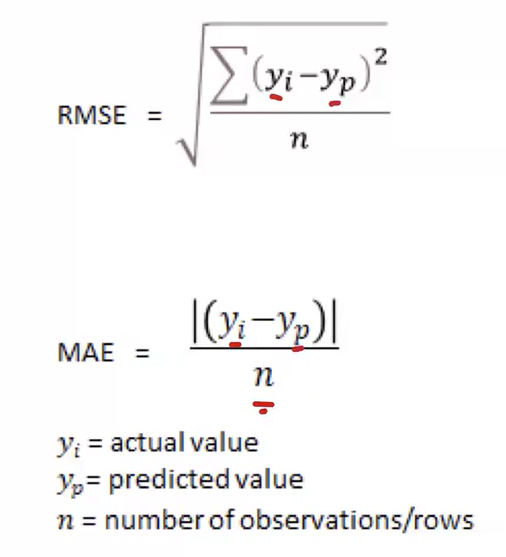
- The MAE should be in smaller range. 
- We want the points that are far away from the best-fit line to be optimised. 
- When to use: When u try to care that the model has to predict for the extreame points(not outliers) as well. Like the extreme points should also be considered, in validating a model.
- RMSE is better tahn MAE.
- But when we have outliers, we need to consider ***R squared***.
- Without seeing data, when we are given with MAE, will we know that if the mnodel has done a good job or not. But R sqaured will give a value by which we can judge.
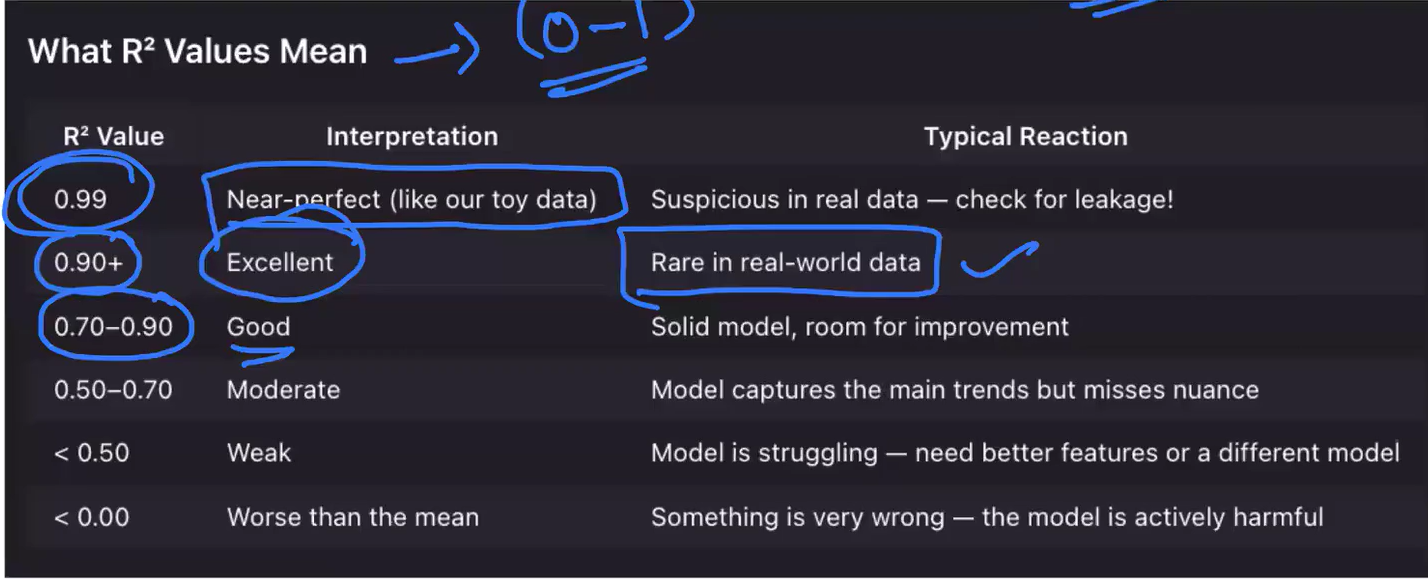

# Calculating r square for the training set of our model

In [23]:
from sklearn.metrics import r2_score

training_r2 = r2_score(y_train,y_train_pred)
print(f"training_r2: {training_r2}")

training_r2: 0.8015753782439603


In [24]:
testing_r2 = r2_score(y_test,y_test_pred)
print(f"testing_r2: {testing_r2}")

testing_r2: 0.7359948378848242


## We can improve the score by using different algo's and refining the dataset more.

## UnderFit || OverFit || BestFit

- **Underfitting**: The model simply misses 90% of the points. It is just waste.
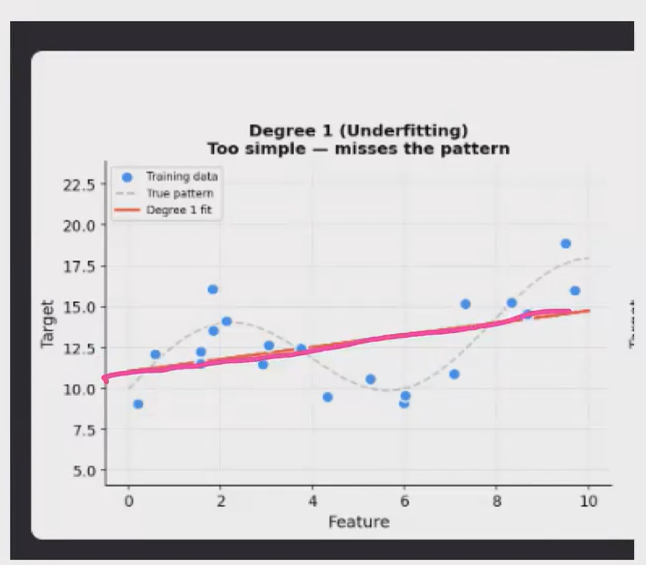
- **Best Fit**: The model tries to learns from the data and meetup 80-90 % of the points 
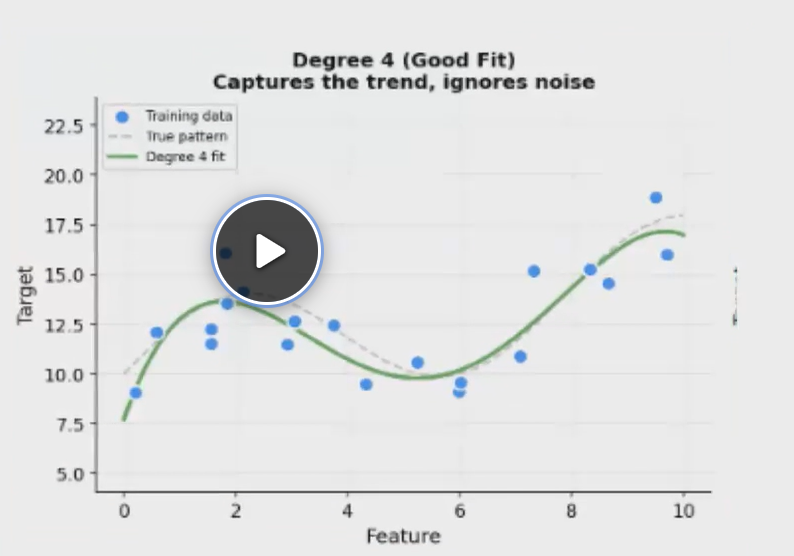
- **Overfitting** : Sometimes the model catches 100% of the points. It's like mugging up and vomiting everything. Too perfect for an ML model. It is not learning the points. It like a code that works only for the hard-coded values. Any new data, it fails.
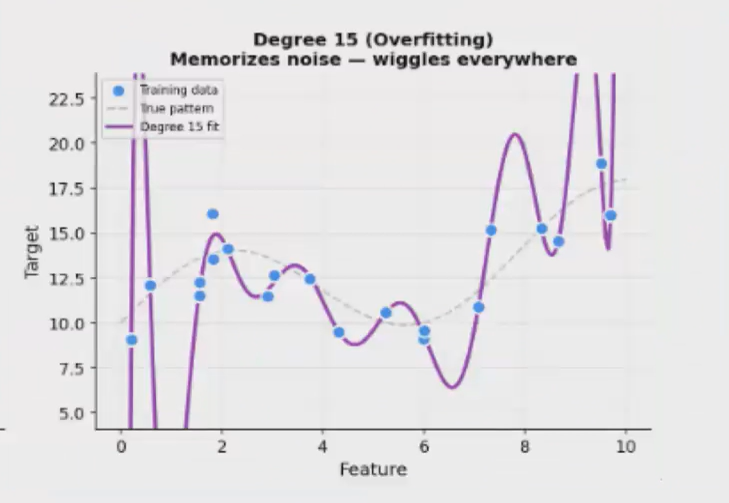

## BIAS(Underfitting) VARIANCE(Overfitting) TRADE OFF

- A model is best when we have low bias and low variance.
- We dont want a model to be too simple simple with our data and too sensitive with our data.
- If my R^2 is <= 0.5, then it is just  a base model, nothing else. A worst one. Out R^2 should be as close as 1 to be **Best Fit model**

## Regularization
- Regularization helps prevent overfitting, but excessive regularization may lead to underfitting.
- Regularization is a technique used to prevent overfitting in machine learning models.
- It works by adding a penalty term (alpha) to the model's loss function.
- This penalty gets added to the prediction error during training.
- Total Loss = Error + Penalty
- The penalty forces the model to keep the weights (coefficients) smaller.
- Smaller weights reduce model complexity and make the model less sensitive to noise in the training data.
- Larger weights result in a larger penalty, which increases the total loss.
- Because of this, the model avoids using excessively large weights unless they significantly improve predictions.
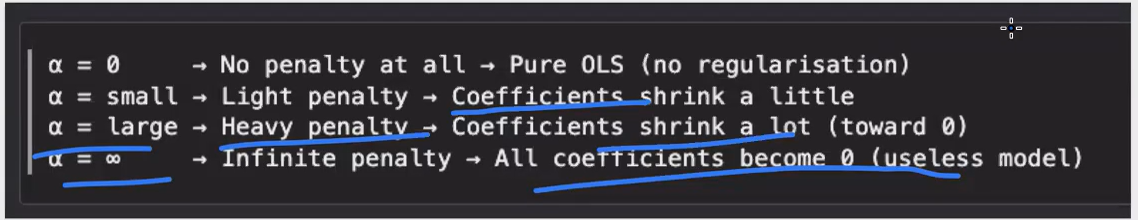
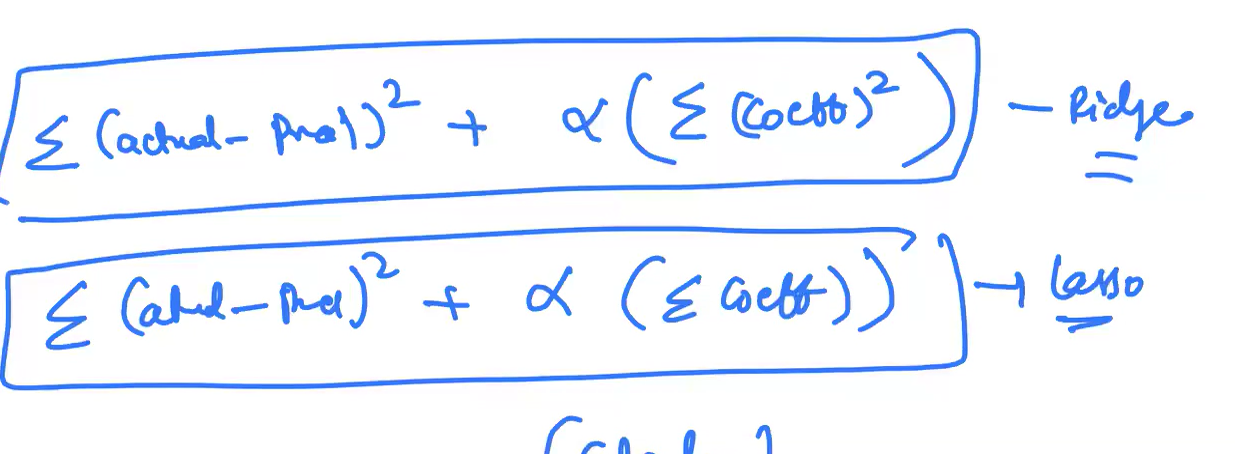

In [25]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score



### R2 Score for the traing and testing model.

In [26]:
r2_train =r2_score(y_train,y_train_pred)
r2_test =r2_score(y_test,y_test_pred)
print(f"R2 score for training data: {r2_train:.4f}")
print(f"R2 score for testing data: {r2_test:.4f}")


R2 score for training data: 0.8016
R2 score for testing data: 0.7360
